In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib import image
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle
import numpy as np
from collections import Counter
from scipy.spatial import cKDTree as KDT
from astropy.table import Column, Table
import itertools
import copy
import scipy.signal
from scipy.spatial import distance
import math
import sys
import pdb
import pickle as pickle
from astropy.convolution import convolve, Gaussian2DKernel
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import ascii
import mpl_scatter_density
from scipy.stats import gaussian_kde, kde
from spisea import synthetic, evolution, atmospheres, reddening, ifmr
from spisea.imf import imf, multiplicity
import pdb
import pylab as py
from flystar import match, transforms, plots, align
from flystar import starlists
from flystar.starlists import StarList
from flystar.startables import StarTable
from astropy.table import Table, Column, vstack
import flystar
import datetime
import copy
import os
import pdb
import time
import warnings
from astropy.utils.exceptions import AstropyUserWarning

/opt/homebrew/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /Users/devaldeliwala/research/code/SPISEA/models/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [23]:
N1_115_catalog = Table.read("catalogs/dr2/NRCB1_catalog115w.csv").to_pandas()
N1_212_catalog = Table.read("catalogs/dr2/NRCB1_catalog212n.csv").to_pandas()
N2_115_catalog = Table.read("catalogs/dr2/NRCB2_catalog115w.csv").to_pandas()
N2_212_catalog = Table.read("catalogs/dr2/NRCB2_catalog212n.csv").to_pandas()
N3_115_catalog = Table.read("catalogs/dr2/NRCB3_catalog115w.csv").to_pandas()
N3_212_catalog = Table.read("catalogs/dr2/NRCB3_catalog212n.csv").to_pandas()
N4_115_catalog = Table.read("catalogs/dr2/NRCB4_catalog115w.csv").to_pandas()
N4_212_catalog = Table.read("catalogs/dr2/NRCB4_catalog212n.csv").to_pandas()
N5_323_catalog = Table.read("catalogs/dr2/NRCB5_catalog323n.csv").to_pandas()
N5_405_catalog = Table.read("catalogs/dr2/NRCB5_catalog405n.csv").to_pandas()

print(f"NEW NRCB1 F115W: {len(N1_115_catalog)}")
print(f"NEW NRCB1 F212N: {len(N1_212_catalog)}")
print(f"NEW NRCB2 F115W: {len(N2_115_catalog)}")
print(f"NEW NRCB2 F212N: {len(N2_212_catalog)}")
print(f"NEW NRCB3 F115W: {len(N3_115_catalog)}")
print(f"NEW NRCB3 F212N: {len(N3_212_catalog)}")
print(f"NEW NRCB4 F115W: {len(N4_115_catalog)}")
print(f"NEW NRCB4 F212N: {len(N4_212_catalog)}")
print(f"NEW NRCB5 F323N: {len(N5_323_catalog)}")
print(f"NEW NRCB5 F405N: {len(N5_405_catalog)}")

NEW NRCB1 F115W: 53620
NEW NRCB1 F212N: 121349
NEW NRCB2 F115W: 39326
NEW NRCB2 F212N: 115254
NEW NRCB3 F115W: 38482
NEW NRCB3 F212N: 115353
NEW NRCB4 F115W: 44077
NEW NRCB4 F212N: 119177
NEW NRCB5 F323N: 145122
NEW NRCB5 F405N: 129316


In [3]:
N1_115_x, N1_115_y = N1_115_catalog['x'], N1_115_catalog['y']
N1_212_x, N1_212_y = N1_212_catalog['x'], N1_212_catalog['y']
N2_115_x, N2_115_y = N2_115_catalog['x'], N2_115_catalog['y']
N2_212_x, N2_212_y = N2_212_catalog['x'], N2_212_catalog['y']
N3_115_x, N3_115_y = N3_115_catalog['x'], N3_115_catalog['y']
N3_212_x, N3_212_y = N3_212_catalog['x'], N3_212_catalog['y']
N4_115_x, N4_115_y = N4_115_catalog['x'], N4_115_catalog['y']
N4_212_x, N4_212_y = N4_212_catalog['x'], N4_212_catalog['y']
N5_323_x, N5_323_y = N5_323_catalog['x'], N5_323_catalog['y']
N5_405_x, N5_405_y = N5_405_catalog['x'], N5_405_catalog['y']

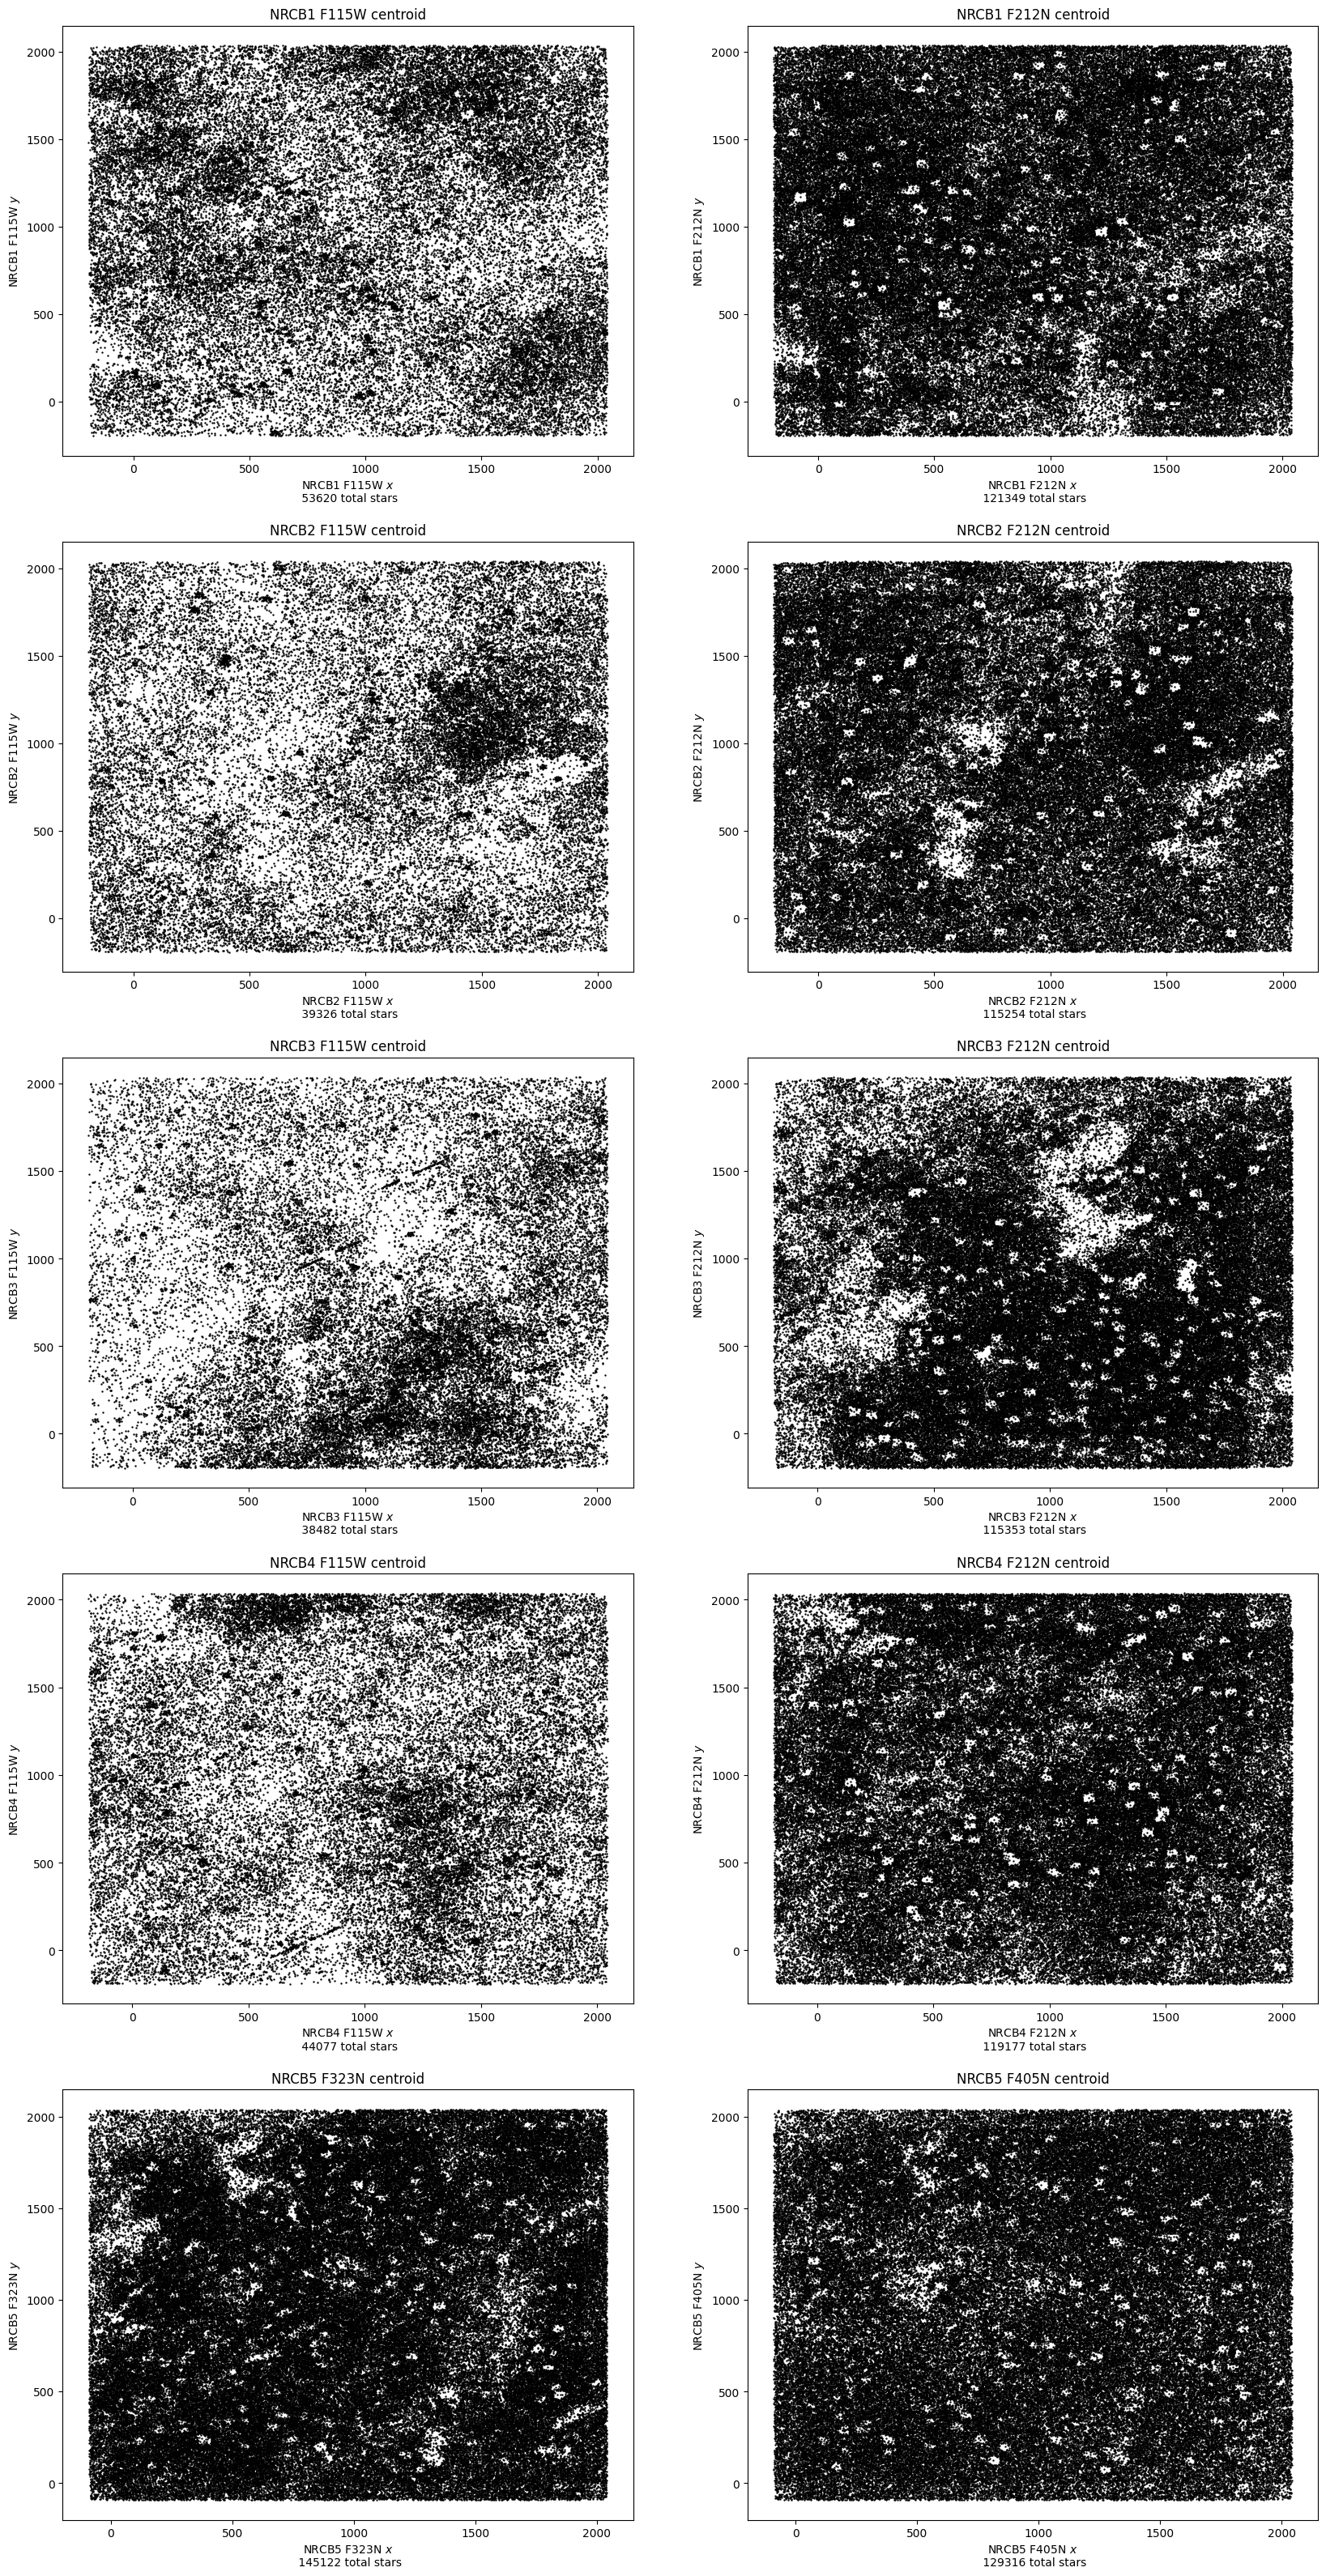

In [22]:
fig, axis = plt.subplots(5, 2, figsize = (20,40))

axis[0,0].scatter(N1_115_x, N1_115_y, c = 'k', s = 0.5)
axis[0,1].scatter(N1_212_x, N1_212_y, c = 'k', s = 0.5)
axis[1,0].scatter(N2_115_x, N2_115_y, c = 'k', s = 0.5)
axis[1,1].scatter(N2_212_x, N2_212_y, c = 'k', s = 0.5)
axis[2,0].scatter(N3_115_x, N3_115_y, c = 'k', s = 0.5)
axis[2,1].scatter(N3_212_x, N3_212_y, c = 'k', s = 0.5)
axis[3,0].scatter(N4_115_x, N4_115_y, c = 'k', s = 0.5)
axis[3,1].scatter(N4_212_x, N4_212_y, c = 'k', s = 0.5)
axis[4,0].scatter(N5_323_x, N5_323_y, c = 'k', s = 0.5)
axis[4,1].scatter(N5_405_x, N5_405_y, c = 'k', s = 0.5)

axis[0,0].set_xlabel(f'NRCB1 F115W $x$ \n {len(N1_115_x)} total stars')
axis[0,0].set_ylabel(f'NRCB1 F115W $y$')
axis[0,1].set_xlabel(f'NRCB1 F212N $x$ \n {len(N1_212_x)} total stars')
axis[0,1].set_ylabel(f'NRCB1 F212N $y$')
axis[1,0].set_xlabel(f'NRCB2 F115W $x$ \n {len(N2_115_x)} total stars')
axis[1,0].set_ylabel(f'NRCB2 F115W $y$')
axis[1,1].set_xlabel(f'NRCB2 F212N $x$ \n {len(N2_212_x)} total stars')
axis[1,1].set_ylabel(f'NRCB2 F212N $y$')
axis[2,0].set_xlabel(f'NRCB3 F115W $x$ \n {len(N3_115_x)} total stars')
axis[2,0].set_ylabel(f'NRCB3 F115W $y$')
axis[2,1].set_xlabel(f'NRCB3 F212N $x$ \n {len(N3_212_x)} total stars')
axis[2,1].set_ylabel(f'NRCB3 F212N $y$')
axis[3,0].set_xlabel(f'NRCB4 F115W $x$ \n {len(N4_115_x)} total stars')
axis[3,0].set_ylabel(f'NRCB4 F115W $y$')
axis[3,1].set_xlabel(f'NRCB4 F212N $x$ \n {len(N4_212_x)} total stars')
axis[3,1].set_ylabel(f'NRCB4 F212N $y$')
axis[4,0].set_xlabel(f'NRCB5 F323N $x$ \n {len(N5_323_x)} total stars')
axis[4,0].set_ylabel(f'NRCB5 F323N $y$')
axis[4,1].set_xlabel(f'NRCB5 F405N $x$ \n {len(N5_405_x)} total stars')
axis[4,1].set_ylabel(f'NRCB5 F405N $y$')

axis[0,0].set_title("NRCB1 F115W centroid")
axis[0,1].set_title("NRCB1 F212N centroid")
axis[1,0].set_title("NRCB2 F115W centroid")
axis[1,1].set_title("NRCB2 F212N centroid")
axis[2,0].set_title("NRCB3 F115W centroid")
axis[2,1].set_title("NRCB3 F212N centroid")
axis[3,0].set_title("NRCB4 F115W centroid")
axis[3,1].set_title("NRCB4 F212N centroid")
axis[4,0].set_title("NRCB5 F323N centroid")
axis[4,1].set_title("NRCB5 F405N centroid")

filename = 'all_centroid_pos.png'
plt.savefig(f"/Users/devaldeliwala/research/jwst/plots/{filename}")